In [3]:
import json
import pickle
from random import random
from collections import Counter
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import seaborn as sns
import scikit_posthocs as sp

from rdkit import Chem
import json
import matplotlib.pyplot as plt
from HADES.featurize import Featurizer
from HADES.correlation_drop import CorrDrop
from HADES.ml_modeling import HPOptimizer
featurizer = Featurizer()


In [5]:
df=pd.read_csv(r'initial_data_for_HADES_pipeline.csv')
smiles = df['SMILES']

In [7]:
data_featurized = featurizer.featurize_many_smiles(smiles)
print(f'All features data shape: {data_featurized.shape}')
na_dropped_data = featurizer.drop_na_cols(data_featurized)
same_val_dropped_data = featurizer.drop_same_val_cols(na_dropped_data)
print(f'Invalid features dropped shape: {same_val_dropped_data.shape}')

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(same_val_dropped_data, df['phase'], random_state=42,
													test_size=0.2)

In [ ]:
model = RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=42)
corrdrop = CorrDrop(model)
cv_thresh_dict, cv_thresh_std_dict = corrdrop.get_corr_threshold(X_train, y_train)
keep_cols, opt_threshold = corrdrop.get_cols_to_keep(X_train, cv_thresh_dict, cv_thresh_std_dict)
print(keep_cols, opt_threshold)
print(len(keep_cols))

In [ ]:
X_train_final, X_test_final = X_train[keep_cols], X_test[keep_cols]
X_train_final.columns = X_train_final.columns.astype(str)
X_test_final.columns = X_test_final.columns.astype(str)

In [9]:
#saving train test datas for further usage

import os

path = 'train_test_saved'
os.makedirs(path, exist_ok=True)

X_train_final_save = X_train_final.copy()
X_train_final_save['SMILES'] = df.loc[list(X_train_final.index), 'SMILES']

X_test_final_save = X_test_final.copy()
X_test_final_save['SMILES'] = df.loc[list(X_test_final.index), 'SMILES']

X_train_final_save.columns = X_train_final_save.columns.astype(str)
X_test_final_save.columns = X_test_final_save.columns.astype(str)

# Save files
X_train_final_save.to_parquet(os.path.join(path, 'X_train.parquet'))
X_test_final_save.to_parquet(os.path.join(path, 'X_test.parquet'))

y_train.to_csv(os.path.join(path, 'y_train.csv'))
y_test.to_csv(os.path.join(path, 'y_test.csv'))

In [ ]:
param_spaces = {
	RandomForestClassifier: {
		"params": {
			"n_estimators": ("int", 200, 1500, 100),
			"max_features": ("categorical", ['sqrt', 'log2', 100, 200, 300]),
			"max_depth": ("int", 2, 50, 2),
			"criterion": ("categorical", ['gini', 'entropy', 'log_loss']),
			"min_samples_split": ("int", 2, 20, 2),
			"bootstrap": ("categorical", [True, False]),
		},
		"extra_args": {"n_jobs": -1, "random_state": 42},
	},
	HistGradientBoostingClassifier: {
		"params": {
			"max_iter": ("int", 200, 1500, 100),
			"max_features": ("float", 0.3, 1.0),
			"learning_rate": ("loguniform", 0.01, 0.5),
			"max_depth": ("int", 2, 10, 1),
			"max_bins": ("int", 63, 255, 16),
			"min_samples_leaf": ("int", 1, 101, 2),
		},
		"extra_args": {"random_state": 42},
	},
	XGBClassifier: {
		"params": {
			"n_estimators": ("int", 200, 1500, 100),
			"learning_rate": ("loguniform", 0.01, 0.5),
			"max_depth": ("int", 2, 10, 1),
			"subsample": ("float", 0.6, 1.0),
			"colsample_bytree": ("float", 0.3, 1.0),
		},
		"extra_args": {"device": "cuda", "seed": 42},
	},
	CatBoostClassifier: {
		"params": {
			"iterations": ("int", 100, 5000, 100),
			"learning_rate": ("loguniform", 0.01, 0.5),
			"depth": ("int", 2, 10, 1),
			"l2_leaf_reg": ("loguniform", 1, 5),
			"border_count": ("int", 32, 128, 32),
		},
		"extra_args": {"verbose": 0, "task_type": "CPU", "devices": "0", "random_seed": 42},
	},
	LGBMClassifier: {
		"params": {
			"n_estimators": ("int", 200, 1500, 100),
			"learning_rate": ("loguniform", 0.01, 0.5),
			"max_depth": ("int", 2, 10, 1),
			"num_leaves": ("int", 30, 100, 10),
			"min_data_in_leaf": ("int", 5, 50, 5),
		},
		"extra_args": {"verbose": -1, "n_jobs": -1, "random_state": 42},
	},
}

y = y_train
y = np.array(y == 4).reshape(-1, )
X = X_train_final
optimizer = HPOptimizer(param_spaces, X, y)
results = optimizer.param_search()

In [10]:
#saving hyperparameters

# import json
# with open("./HADES_models_hyperparameters.json", "w") as f:
# 	json.dump(results, f, indent=4)

In [12]:
with open("./HADES_models_hyperparameters.json", "r") as f:
    results = json.load(f)


In [13]:
# import pandas as pd
X_train_final = pd.read_parquet(r'./train_test_saved/X_train.parquet')
X_test_final = pd.read_parquet(r'./train_test_saved/X_test.parquet')
y_test =pd.read_csv(r'./train_test_saved/y_test.csv',index_col = 0)
y_train=pd.read_csv(r'./train_test_saved/y_train.csv',index_col = 0)
descriptors = list(X_train_final.columns)[:-1]
best_params_dict = {
    model: {'best_params': values['best_params']}
    for model, values in results.items()
}

In [14]:
models = {
    "XGBClassifier": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
#             tree_method='gpu_hist',
        **best_params_dict["XGBClassifier"]["best_params"]
    ),
    "CatBoostClassifier": CatBoostClassifier(
#         class_weights=catboost_class_weights,
        verbose=0,
#             task_type="GPU",
        **best_params_dict["CatBoostClassifier"]["best_params"]
    ),
    "LGBMClassifier": LGBMClassifier(
#             device='gpu',
        **best_params_dict["LGBMClassifier"]["best_params"]
    ),
    "RandomForestClassifier": RandomForestClassifier(
        **best_params_dict["RandomForestClassifier"]["best_params"]
    ),
    "HistGradientBoostingClassifier": HistGradientBoostingClassifier(
        **best_params_dict["HistGradientBoostingClassifier"]["best_params"]
    )
}

from collections import Counter
from sklearn.utils import compute_sample_weight
from tqdm import tqdm
def train_models_with_best_params_and_weights(X_train, y_train, class_weight_scheme, best_params_dict, seed=42):
    y = [int(i/4) for i in y_train['phase']]
    # y = list(y_train['phase'])
    sample_weights = compute_sample_weight(class_weight=class_weight_scheme, y=y)

    class_counts = Counter(y)
    total_samples = sum(class_counts.values())
    catboost_class_weights = {
        0: total_samples / class_counts[0],  # Weight for class 0
        1: total_samples / class_counts[1]   # Weight for class 1
    }
    catboost_class_weights = [total_samples / class_counts[i] for i in sorted(class_counts)]

    # Inject random_state / random_seed into best_params
    for model_name, model_info in best_params_dict.items():
        if model_name == "CatBoostClassifier":
            model_info["best_params"]["random_seed"] = seed
        else:
            model_info["best_params"]["random_state"] = seed

    models = {
        "XGBClassifier": XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            # tree_method='gpu_hist',
            # base_score=0.5,
            **best_params_dict["XGBClassifier"]["best_params"]
        ),
        "CatBoostClassifier": CatBoostClassifier(
            class_weights=catboost_class_weights,
            verbose=0,
            # task_type="GPU",
            **best_params_dict["CatBoostClassifier"]["best_params"]
        ),
        "LGBMClassifier": LGBMClassifier(
            # device='gpu',
            **best_params_dict["LGBMClassifier"]["best_params"]
        ),
        "RandomForestClassifier": RandomForestClassifier(
            **best_params_dict["RandomForestClassifier"]["best_params"]
        ),
        "HistGradientBoostingClassifier": HistGradientBoostingClassifier(
            **best_params_dict["HistGradientBoostingClassifier"]["best_params"]
        )
    }

    trained_models = {}
    for name in tqdm(models, desc="Training models"):
        model = models[name]
        if name == "CatBoostClassifier":
            trained_models[name] = model.fit(X_train, y)
        else:
            trained_models[name] = model.fit(X_train, y, sample_weight=sample_weights)

    return trained_models


In [15]:
# this code trains models

# models_balanced = train_models_with_best_params_and_weights(X_train_final[descriptors],y_train,'balanced',best_params_dict)

In [ ]:

# import joblib # saving models for further imports
# import os
##Create a directory to store models (ensure the directory exists)
# os.makedirs("./HADES_saved_models", exist_ok=True)
#
# #Save each model
# for name, model in models_balanced.items():
   # joblib.dump(model, f"./HADES_saved_models/{name}.pkl")


# #import models
# import joblib
# import os
# # Load models into a new dictionary
# models_balanced = {}
#
# for name in models.keys():
#     models_balanced[name] = joblib.load(f"HADES_saved_models/{name}.pkl")
# models_balanced


In [ ]:
# Models have large size, so load them from figshare as done below

In [17]:
import requests
import joblib
import io

ARTICLE_ID = 32084259  # from your DOI: 10.6084/m9.figshare.32084259

# Fetch all file metadata from the article
api_url = f"https://api.figshare.com/v2/articles/{ARTICLE_ID}/files"
files_info = requests.get(api_url).json()

# Preview what files are available
for f in files_info:
    print(f["name"], "→", f["download_url"])

XGBClassifier.pkl → https://ndownloader.figshare.com/files/63957510
LGBMClassifier.pkl → https://ndownloader.figshare.com/files/63957513
HistGradientBoostingClassifier.pkl → https://ndownloader.figshare.com/files/63957516
CatBoostClassifier.pkl → https://ndownloader.figshare.com/files/63957519
RandomForestClassifier.pkl → https://ndownloader.figshare.com/files/63957522


In [18]:
# Build name → download_url map (strips .pkl extension for matching)
figshare_urls = {
    f["name"].replace(".pkl", ""): f["download_url"]
    for f in files_info
    if f["name"].endswith(".pkl")
}

models_balanced = {}

for name in models.keys():
    if name not in figshare_urls:
        print(f"⚠️  '{name}' not found in Figshare article")
        continue

    response = requests.get(figshare_urls[name])
    response.raise_for_status()

    models_balanced[name] = joblib.load(io.BytesIO(response.content))
    print(f"✓ Loaded {name}")

models_balanced

✓ Loaded XGBClassifier
✓ Loaded CatBoostClassifier
✓ Loaded LGBMClassifier
✓ Loaded RandomForestClassifier
✓ Loaded HistGradientBoostingClassifier


{'XGBClassifier': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.305304953282015, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric='logloss', feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.055647309275537314,
               max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=1200, n_jobs=None,
               num_parallel_tree=None, ...),
 'CatBoostClassifier': <catboost.core.CatBoostClassifier at 0x79b5bb5a3160>,
 'LGBMClassifier': LGBMClassifier(learning_rate=0.2446974201697101, max_depth=9,
      

In [19]:
def predict_ensemble(models_dict, new_test_set):
    prob_preds = [model.predict_proba(new_test_set)[:, 1] for model in models_dict.values()]
    final_pred_prob = np.mean(prob_preds, axis=0)
    return final_pred_prob


In [ ]:
# ML models performance

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.utils import resample

# -------------------------------------------------
# METRIC CONFIGURATION
# -------------------------------------------------
metrics = {
    "accuracy": (accuracy_score, False),
    "balanced_accuracy": (balanced_accuracy_score, False),
    "f1": (f1_score, False),
    "precision": (precision_score, False),
    "recall": (recall_score, False),
    "roc_auc": (roc_auc_score, True),
}

# -------------------------------------------------
# Convert y to proper binary (0 / 1)
# -------------------------------------------------
y_test_binary = (y_test['phase'] == 4).astype(int).values

# -------------------------------------------------
# HELPER: get predictions
# -------------------------------------------------
def get_predictions(model, X, needs_proba):
    if needs_proba:
        return model.predict_proba(X)[:, 1]  # positive class now is 1
    return model.predict(X)

# -------------------------------------------------
# BOOTSTRAP FOR SINGLE MODEL
# -------------------------------------------------
def bootstrap_metric_ci(model, X_test, y_test, metric_fn,
                        n_iterations=1000, ci=95, needs_proba=False):
    scores = []
    for _ in range(n_iterations):
        X_resampled, y_resampled = resample(
            X_test, y_test, n_samples=len(X_test)
        )
        y_pred = get_predictions(model, X_resampled, needs_proba)
        score = metric_fn(y_resampled, y_pred)
        scores.append(score)
    mean = np.mean(scores)
    lower = np.percentile(scores, (100 - ci) / 2)
    upper = np.percentile(scores, 100 - (100 - ci) / 2)
    return mean, lower, upper

# -------------------------------------------------
# ENSEMBLE FUNCTIONS
# -------------------------------------------------
def ensemble_predict_proba(models_dict, X):
    prob_preds = [model.predict_proba(X)[:, 1] for model in models_dict.values()]
    return np.mean(prob_preds, axis=0)

def ensemble_predict_labels(models_dict, X):
    probs = ensemble_predict_proba(models_dict, X)
    return (probs >= 0.5).astype(int)

def bootstrap_metric_ci_ensemble(models_dict, X_test, y_test,
                                 metric_fn, n_iterations=1000,
                                 ci=95, needs_proba=False):
    scores = []
    for _ in range(n_iterations):
        X_resampled, y_resampled = resample(
            X_test, y_test, n_samples=len(X_test)
        )
        if needs_proba:
            y_pred = ensemble_predict_proba(models_dict, X_resampled)
        else:
            y_pred = ensemble_predict_labels(models_dict, X_resampled)
        score = metric_fn(y_resampled, y_pred)
        scores.append(score)
    mean = np.mean(scores)
    lower = np.percentile(scores, (100 - ci) / 2)
    upper = np.percentile(scores, 100 - (100 - ci) / 2)
    return mean, lower, upper

# -------------------------------------------------
# EVALUATE ALL MODELS
# -------------------------------------------------
results = {}
for model_key, model in models_balanced.items():
    results[model_key] = {}
    for metric_name, (metric_fn, needs_proba) in metrics.items():
        mean, lower, upper = bootstrap_metric_ci(
            model,
            X_test_final[descriptors],
            y_test_binary,  # ✅ use binary labels everywhere
            metric_fn,
            n_iterations=1000,
            ci=95,
            needs_proba=needs_proba
        )
        results[model_key][metric_name] = (mean, lower, upper)

# -------------------------------------------------
# EVALUATE ENSEMBLE
# -------------------------------------------------
results["Ensemble"] = {}
for metric_name, (metric_fn, needs_proba) in metrics.items():
    mean, lower, upper = bootstrap_metric_ci_ensemble(
        models_balanced,
        X_test_final[descriptors],
        y_test_binary,  # ✅ binary
        metric_fn,
        n_iterations=1000,
        ci=95,
        needs_proba=needs_proba
    )
    results["Ensemble"][metric_name] = (mean, lower, upper)

# -------------------------------------------------
# PRINT RESULTS
# -------------------------------------------------
for model_key, metric_dict in results.items():
    print(f"\n==============================")
    print(f"Model: {model_key}")
    print(f"==============================")
    for metric_name, (mean, lower, upper) in metric_dict.items():
        print(
            f"{metric_name:20s}: "
            f"{mean:.3f}  "
            f"[{lower:.3f}, {upper:.3f}]"
        )

In [ ]:
import pandas as pd

# List of metrics and models
metrics_list = list(next(iter(results.values())).keys())  # e.g., ["accuracy", "f1", ...]
model_list = list(results.keys())

# Build a dictionary for the DataFrame
data = {}
for metric in metrics_list:
    row = {}
    for model in model_list:
        mean, lower, upper = results[model][metric]
        row[model] = f"{mean:.3f} [{lower:.3f}, {upper:.3f}]"
    data[metric] = row

# Create DataFrame
results_table = pd.DataFrame(data).T  # transpose so metrics are rows
results_table.index.name = "Metric"

# Show table
results_table

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils._tags import ClassifierTags
import pandas as pd
import numpy as np

# --- 1. Define your ensemble wrapper ---
class EnsembleMeanModel(BaseEstimator, ClassifierMixin):

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"
        tags.classifier_tags = ClassifierTags()
        tags.target_tags.required = True
        return tags

    def __init__(self, models_dict):
        self.models_dict = models_dict
        self.classes_ = np.array([0, 1])
        self.__sklearn_tags__().estimator_type = "classifier"

    def predict(self, X):
        preds = [model.predict(X) for model in self.models_dict.values()]
        return np.mean(preds, axis=0).round().astype(int)

    def predict_proba(self, X):
        preds = [model.predict_proba(X) for model in self.models_dict.values()]
        return np.mean(preds, axis=0)

    def fit(self, X, y):
        for model in self.models_dict.values():
            model.fit(X, y)
        return self

    def get_params(self, deep=False):
        return {'models_dict': self.models_dict}


# --- 2. Build the ensemble safely (without self-reference) ---
base_models = {name: model for name, model in models_balanced.items() if name != 'EnsembleMean'}
models_balanced['EnsembleMean'] = EnsembleMeanModel(models_dict=base_models)

# --- 3. Compute permutation importance for each model ---
perm_importances_mean = {}
perm_importances_std = {}

for name, model in models_balanced.items():
    print(f"Calculating permutation importance for: {name}")

    result = permutation_importance(
        model,
        X_test_final[descriptors],
        list(y_test['phase']),
        n_repeats=10,
        random_state=42,
        n_jobs=1,
        scoring='roc_auc'
    )

    perm_importances_mean[name] = pd.Series(result.importances_mean, index=X_test_final[descriptors].columns)
    perm_importances_std[name] = pd.Series(result.importances_std, index=X_test_final[descriptors].columns)

# --- 4. Convert to DataFrames ---
df_perm_means = pd.DataFrame(perm_importances_mean)
df_perm_stds = pd.DataFrame(perm_importances_std)



In [ ]:
dfs = []

for model_name, series in perm_importances_mean.items():
    top = series.sort_values(ascending=False).head(len(X_test_final[descriptors].columns))

    df_model = pd.DataFrame({
        f"{model_name} - feature": top.index,
        f"{model_name} - importance value": top.values
    }).reset_index(drop=True)

    dfs.append(df_model)
df_importance_table = pd.concat(dfs, axis=1)
df_importance_table.head(20)

In [22]:
#in this dataframe all molecules represented in SMILES and all score are already calculated
candidates_test = pd.read_csv(r'clinical_candidates_test_scores.csv')

/tmp/ipykernel_95331/1449333185.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(



IQR for HADES:
  Phase 0: IQR = 0.044
  Phase 1: IQR = 0.388
  Phase 2: IQR = 0.518
  Phase 3: IQR = 0.705
  Phase 4: IQR = 0.687


/tmp/ipykernel_95331/1449333185.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(



IQR for QED:
  Phase 0: IQR = 0.208
  Phase 1: IQR = 0.296
  Phase 2: IQR = 0.305
  Phase 3: IQR = 0.302
  Phase 4: IQR = 0.296

IQR for DBPP_SCORE:
  Phase 0: IQR = 0.896
  Phase 1: IQR = 0.596
  Phase 2: IQR = 0.816
  Phase 3: IQR = 0.956
  Phase 4: IQR = 0.007


/tmp/ipykernel_95331/1449333185.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_95331/1449333185.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(



IQR for MolSkill:
  Phase 0: IQR = 12.249
  Phase 1: IQR = 10.823
  Phase 2: IQR = 10.679
  Phase 3: IQR = 12.022
  Phase 4: IQR = 11.700


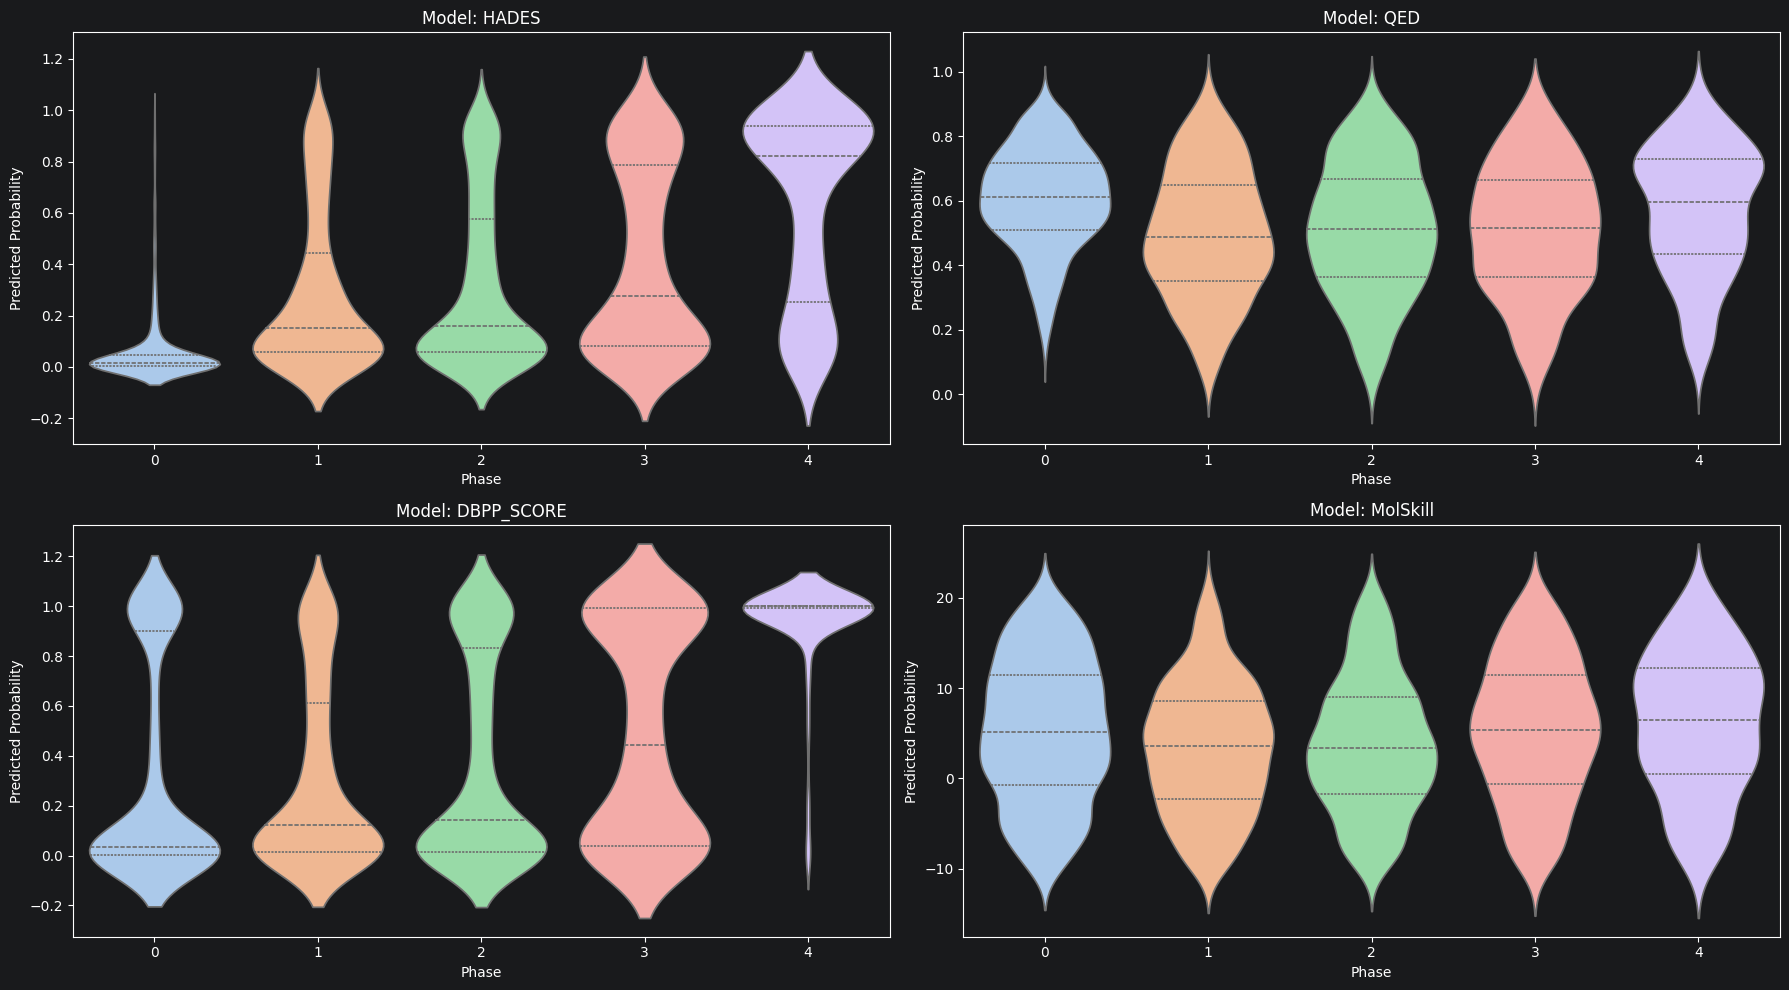

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_violin_collage(df, model_names, acc_list=None):

    # ---- Filter MolSkill between 5th and 95th percentiles ----
    low = df['MolSkill'].quantile(0.05)
    high = df['MolSkill'].quantile(0.95)
    df_filtered = df[(df['MolSkill'] >= low) & (df['MolSkill'] <= high)]

    # ---------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()

    for i, model in enumerate(model_names):
        ax = axes[i]

        # Prepare the data: phase + one model column
        temp_df = df_filtered[['phase', model]].rename(
            columns={model: 'probability'}
        )

        sns.violinplot(
            x='phase',
            y='probability',
            data=temp_df,
            inner="quartile",
            palette="pastel",
            ax=ax
        )

        ax.set_title(f'Model: {model}', fontsize=12)
        ax.set_xlabel('Phase')
        ax.set_ylabel('Predicted Probability')
        ax.set_xticks([0, 1, 2, 3, 4])

        # ---- Calculate IQR per phase ----
        print(f"\nIQR for {model}:")
        for phase in sorted(temp_df['phase'].unique()):
            phase_probs = temp_df[temp_df['phase'] == phase]['probability']
            q75, q25 = np.percentile(phase_probs, [75 ,25])
            iqr = q75 - q25
            print(f"  Phase {phase}: IQR = {iqr:.3f}")

    plt.tight_layout()
    plt.show()

# Example usage
plot_violin_collage(candidates_test, ['HADES','QED','DBPP_SCORE','MolSkill'])

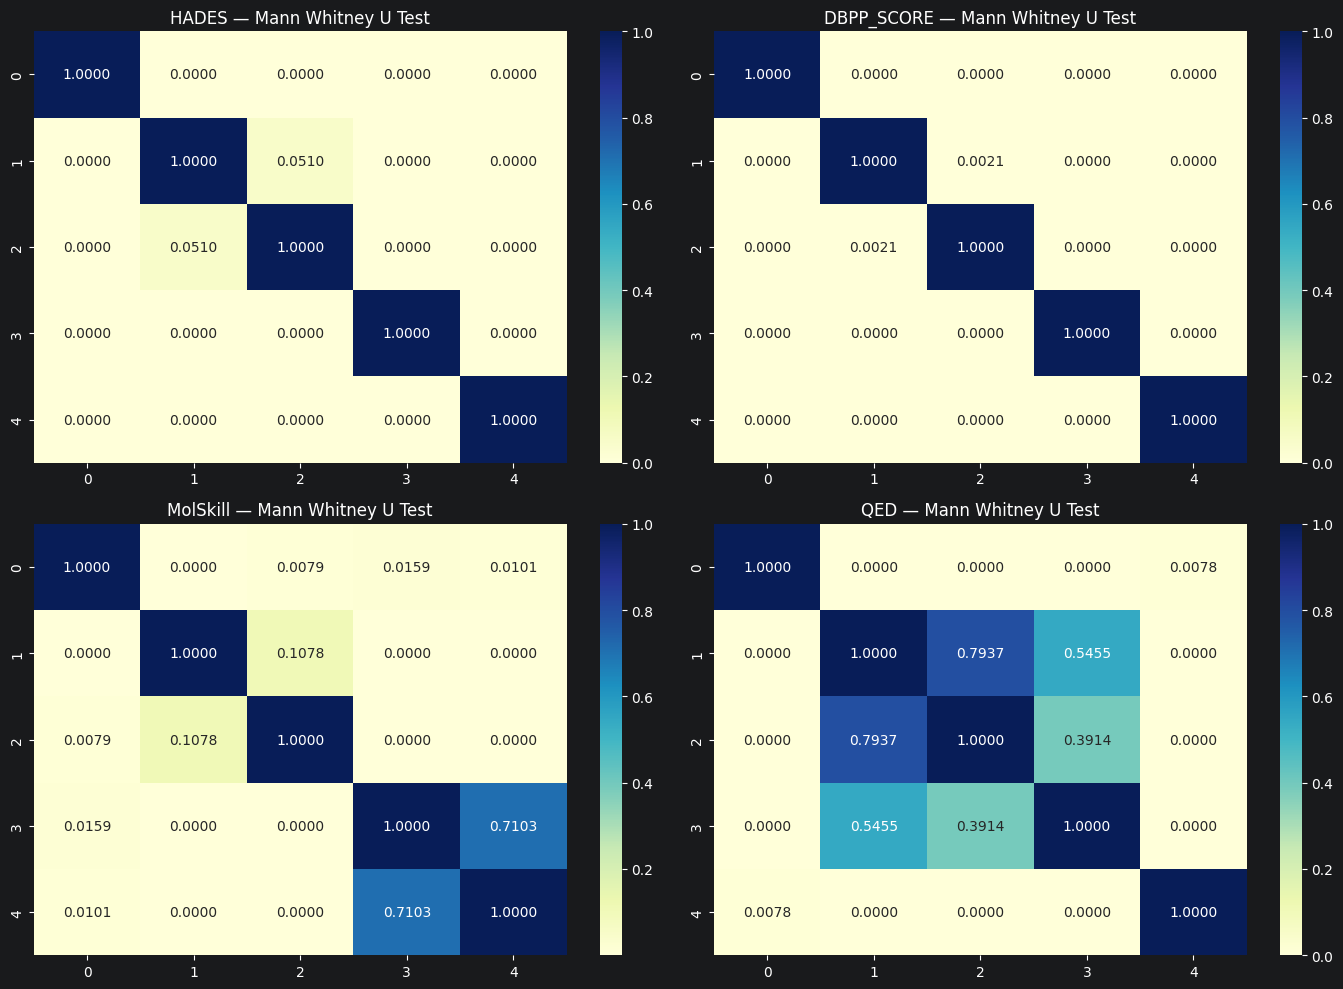

In [24]:
# Mann Whitney U test
columns_to_analyze = ['HADES','DBPP_SCORE', 'MolSkill', 'QED']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(columns_to_analyze):
    # Drop NaNs ONLY for the current column
    df_clean = candidates_test.dropna(subset=[col])

    posthoc = sp.posthoc_mannwhitney(
        df_clean,
        val_col=col,
        group_col='phase'
    )

    sns.heatmap(posthoc, annot=True, cmap="YlGnBu", fmt=".4f", ax=axes[idx])
    axes[idx].set_title(f"{col} — Mann Whitney U Test")

plt.tight_layout()

# ---- Save as TIFF ----
# plt.savefig('mann_whitney_heatmaps_JCIM.tiff', format='tiff', dpi=300, bbox_inches='tight')

plt.show()

In [25]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import itertools


def predict_ensemble_proba(models, new_test_set):
    """Average predicted probabilities from multiple models."""
    prob_preds = [model.predict_proba(new_test_set)[:, 1] for model in models]
    return np.mean(prob_preds, axis=0)


def calculate_auc_mean_std_matrix(phases, y_probs, n_iterations=1000, random_state=42):
    """Compute pairwise AUC mean and std using bootstrap sampling."""

    phase_order = sorted(phases.unique())
    rng = np.random.default_rng(seed=random_state)

    df = pd.DataFrame({
        "phase": phases,
        "y_score": y_probs
    })

    df["phase"] = pd.Categorical(df["phase"], categories=phase_order, ordered=True)

    auc_matrix = pd.DataFrame(index=phase_order, columns=phase_order, dtype=object)

    for p1, p2 in itertools.combinations(phase_order, 2):
        df_pair = df[df["phase"].isin([p1, p2])].copy()

        high = max(p1, p2)
        low = min(p1, p2)

        auc_scores = []

        for _ in range(n_iterations):
            high_group = df_pair[df_pair["phase"] == high]
            low_group = df_pair[df_pair["phase"] == low]

            if high_group.empty or low_group.empty:
                continue

            sample_high = high_group.sample(
                n=len(high_group),
                replace=True,
                random_state=rng
            )

            sample_low = low_group.sample(
                n=len(low_group),
                replace=True,
                random_state=rng
            )

            df_sample = pd.concat([sample_high, sample_low])
            df_sample["binary_label"] = (df_sample["phase"] == high).astype(int)

            if df_sample["binary_label"].nunique() < 2:
                continue

            auc = roc_auc_score(df_sample["binary_label"], df_sample["y_score"])
            auc_scores.append(auc)

        if auc_scores:
            mean_auc = np.mean(auc_scores)
            std_auc = np.std(auc_scores)

            formatted = f"{mean_auc:.2f} ± {std_auc:.2f}"

            auc_matrix.at[low, high] = formatted
            auc_matrix.at[high, low] = formatted

    # Fill diagonal
    for p in phase_order:
        auc_matrix.at[p, p] = "1.00 ± 0.00"

    return auc_matrix

In [26]:
candidates_test_2 = candidates_test.dropna(subset=['MolSkill']).reset_index(drop=True) # some molecules have NaN

In [27]:
#one example below is for HADES, calculate also for other scores
calculate_auc_mean_std_matrix(candidates_test['phase'], candidates_test['DBPP_SCORE'])

,0,1,2,3,4
0,1.00 ± 0.00,0.57 ± 0.01,0.60 ± 0.01,0.68 ± 0.01,0.89 ± 0.01
1,0.57 ± 0.01,1.00 ± 0.00,0.55 ± 0.01,0.65 ± 0.02,0.92 ± 0.01
2,0.60 ± 0.01,0.55 ± 0.01,1.00 ± 0.00,0.60 ± 0.02,0.87 ± 0.01
3,0.68 ± 0.01,0.65 ± 0.02,0.60 ± 0.02,1.00 ± 0.00,0.81 ± 0.02
4,0.89 ± 0.01,0.92 ± 0.01,0.87 ± 0.01,0.81 ± 0.02,1.00 ± 0.00


In [28]:
final_list_4 = candidates_test[candidates_test['phase'] ==4 ].reset_index(drop=True)

In [29]:
new_2024_after_drugs = pd.read_csv(r'compounds dataset/2024 after drugs smi 4 scores.csv')
toxicity_panel= pd.read_csv(r'compounds dataset/oral toxics smi 4 scores.csv')
small_rings = pd.read_csv(r'compounds dataset/small rings smi 4 scores.csv')
odds_final = pd.read_csv('compounds dataset/odd molecules smi 4 scores.csv')

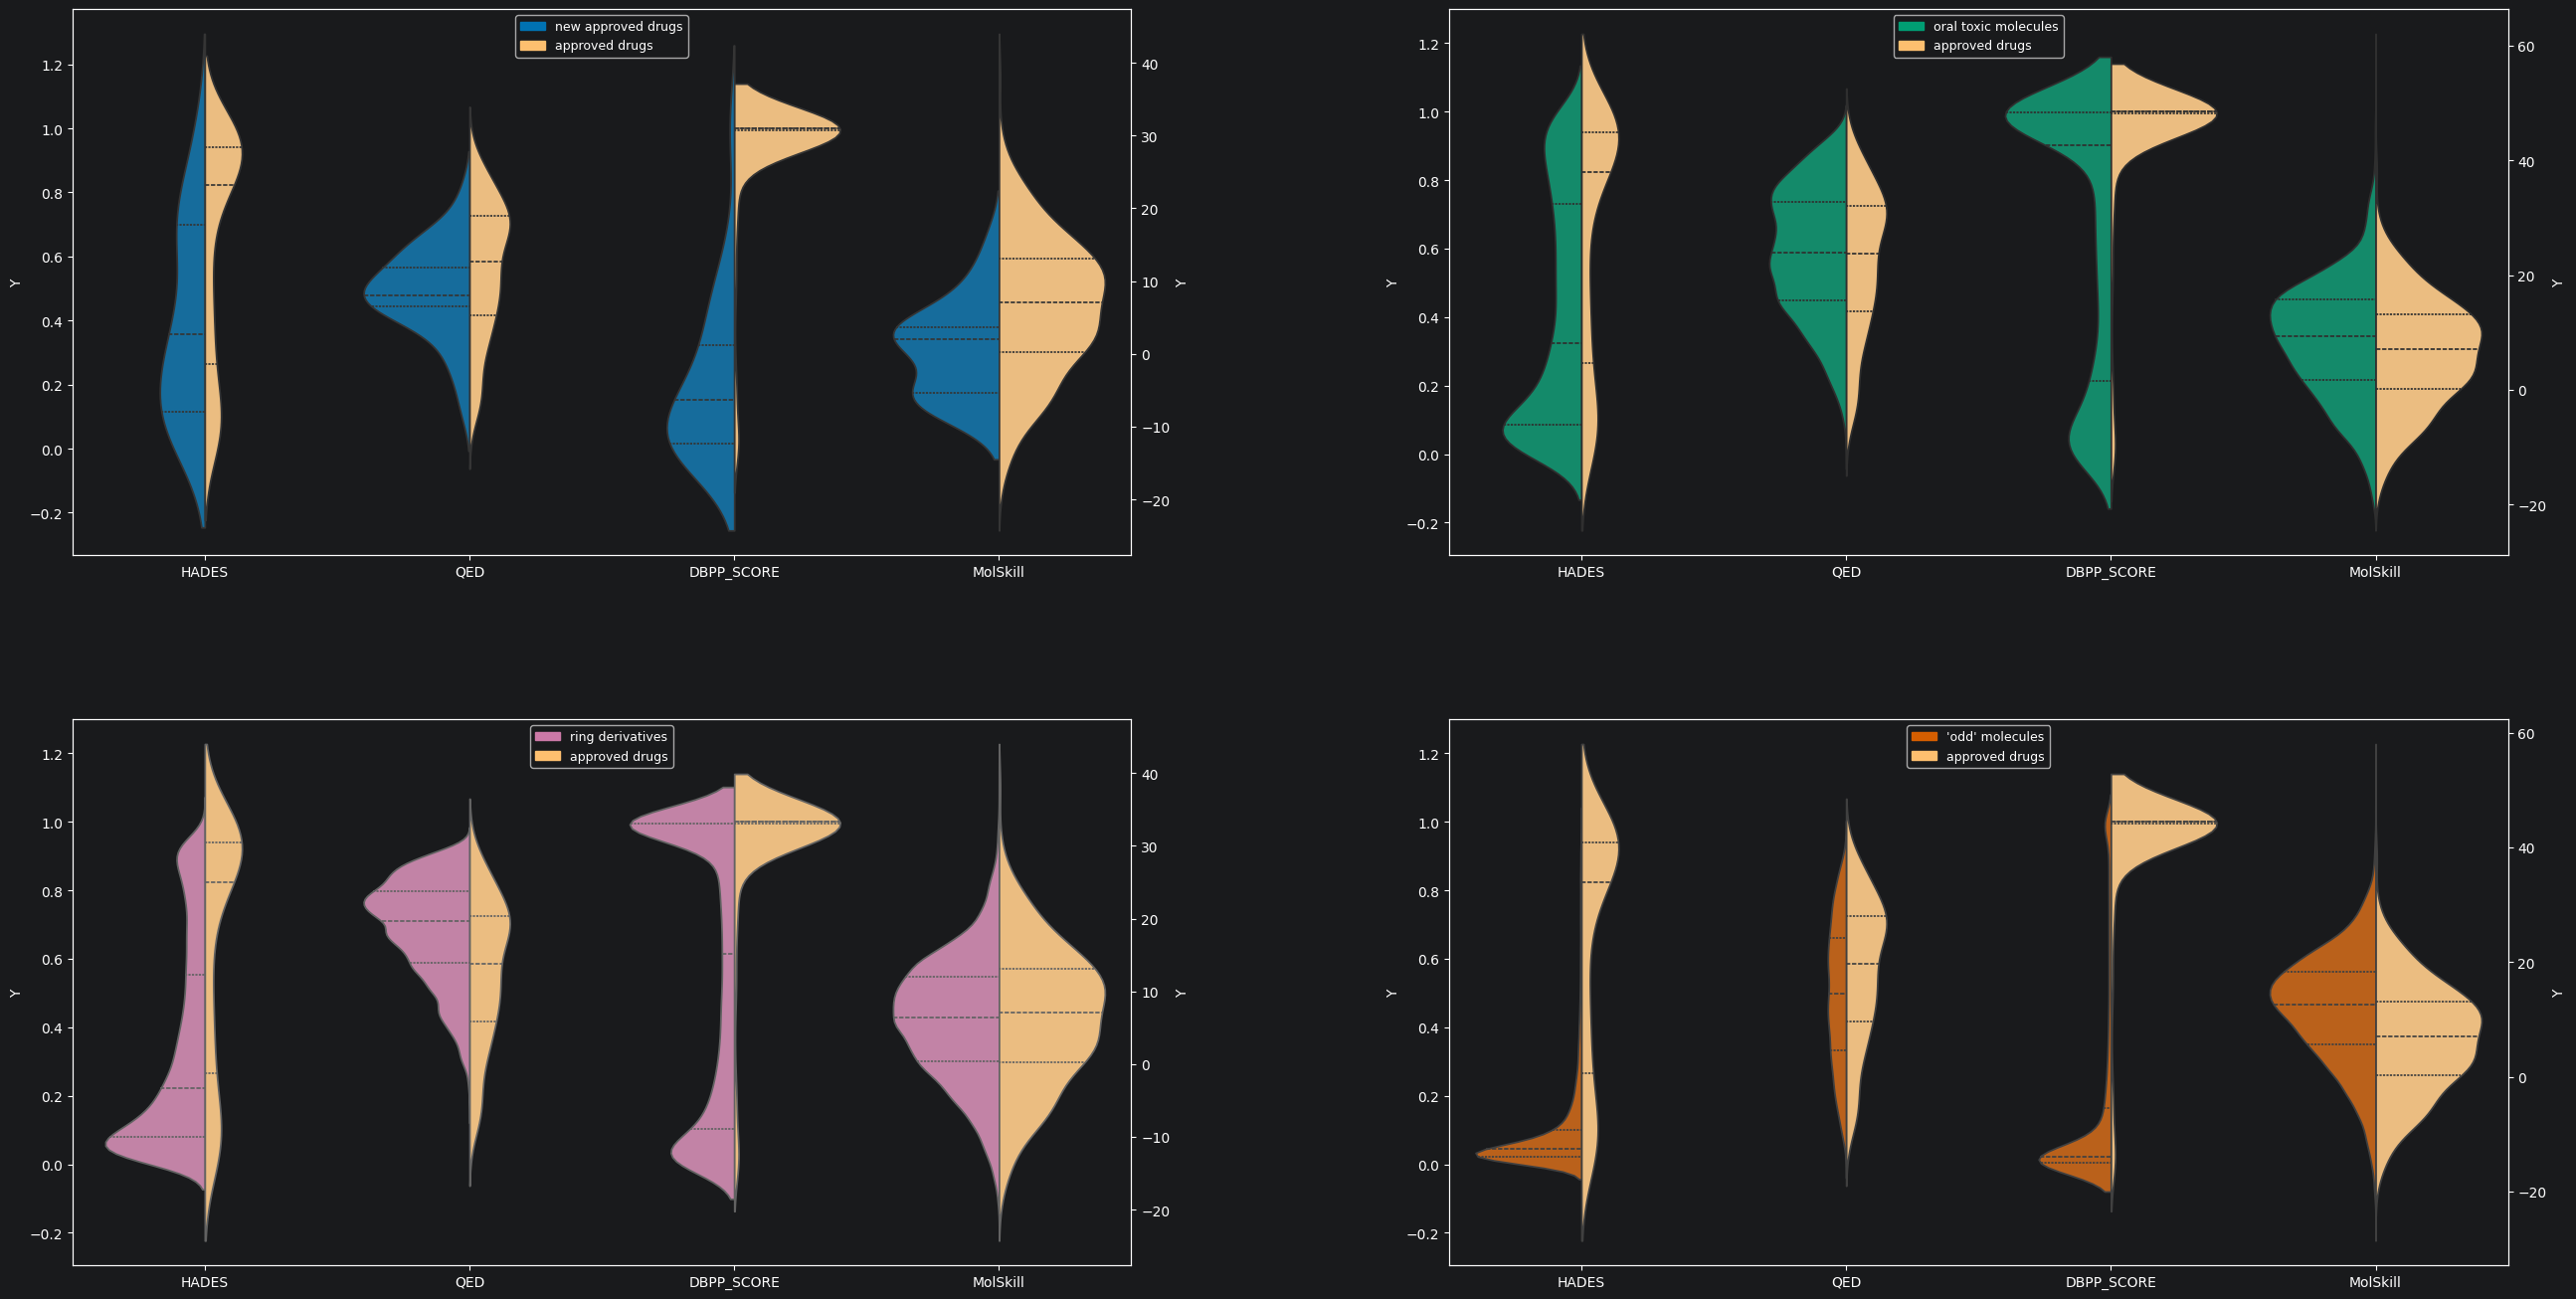

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches

# Define the low and high range scores
low_range_scores = ['HADES', 'QED', 'DBPP_SCORE']
high_range_scores = ['MolSkill']

# Custom labels for the Odds datasets (in order of dataset_pairs)
labels = [
    "new approved drugs",
    "oral toxic molecules",
    "ring derivatives",
    "'odd' molecules"
]

def make_violin_with_twin(ax, df_compounds, df_drugs, compounds_color, compounds_label):
    # Melt datasets for low range
    df1_melted_low = df_compounds[low_range_scores].melt(var_name='Variable', value_name='Y')
    df1_melted_low['Dataset'] = 'Cmpd'
    df2_melted_low = df_drugs[low_range_scores].melt(var_name='Variable', value_name='Y')
    df2_melted_low['Dataset'] = 'final_list_4'
    combined_low = pd.concat([df1_melted_low, df2_melted_low]).reset_index(drop=True)

    # Melt datasets for MolSkill (high range)
    df1_melted_high = df_compounds[high_range_scores].melt(var_name='Variable', value_name='Y')
    df1_melted_high['Dataset'] = 'Cmpd'
    df2_melted_high = df_drugs[high_range_scores].melt(var_name='Variable', value_name='Y')
    df2_melted_high['Dataset'] = 'final_list_4'
    combined_high = pd.concat([df1_melted_high, df2_melted_high]).reset_index(drop=True)

    # Colors
    palette = {'Cmpd': compounds_color, 'final_list_4': '#FDBF6F'}  # Peach

    # Plot low range on main axis
    sns.violinplot(
        x='Variable', y='Y', hue='Dataset',
        data=combined_low, split=True, inner='quart',
        palette=palette, ax=ax
    )
    ax.set_xlabel('')
    ax.legend().remove()

    # Plot MolSkill on twin axis
    ax2 = ax.twinx()
    sns.violinplot(
        x='Variable', y='Y', hue='Dataset',
        data=combined_high, split=True, inner='quart',
        palette=palette, ax=ax2
    )
    ax2.legend().remove()

    # Custom legend on the main axis
    compounds_patch = mpatches.Patch(color=compounds_color, label=compounds_label)
    final_list_patch = mpatches.Patch(color='#FDBF6F', label='approved drugs')  # Light Yellow in legend
    ax.legend(handles=[compounds_patch, final_list_patch], loc='upper center', bbox_to_anchor=(0.5, 1), fontsize=9)

# Example dataset pairs (Replace with actual dataframes)
dataset_pairs = [
    (new_2024_after_drugs, final_list_4),
    (toxicity_panel, final_list_4),
    (small_rings, final_list_4),
    (odds_final, final_list_4)
]

# Colorblind-safe colors
compounds_colors = ['#0072B2', '#009E73', '#CC79A7', '#D55E00']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(26, 14))

# Loop through axes and dataset pairs
for ax, ((df_compounds, df_drugs), compounds_color, compounds_label) in zip(
        axes.flatten(), zip(dataset_pairs, compounds_colors, labels)):
    make_violin_with_twin(ax, df_compounds, df_drugs, compounds_color, compounds_label)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.93, wspace=0.3, hspace=0.3)

# Save the plot (optional)
# plt.savefig("Stress_tests_violinplots.tiff", dpi=300, format='tiff')

# Show the plot
plt.show()


In [31]:
from scipy.stats import mannwhitneyu

# Store results
mannwhitney_results = []
iqr_results = []

# Go through each dataset pair
for (df_compounds, df_drugs), label in zip(dataset_pairs, labels):
    for score in low_range_scores + high_range_scores:
        # Drop NaNs for clean statistical testing
        compounds_values = df_compounds[score].dropna()
        drugs_values = df_drugs[score].dropna()

        # Mann-Whitney U Test (non-parametric test for independent samples)
        stat, p_value = mannwhitneyu(compounds_values, drugs_values, alternative='two-sided')

        mannwhitney_results.append({
            'Comparison': label,
            'Score': score,
            'U_statistic': stat,
            'p_value': p_value,
            'Odds_median': compounds_values.median(),
            'Drugs_median': drugs_values.median()
        })

        # Calculate IQRs
        for name, values in [('CMPD', compounds_values), ('Drugs', drugs_values)]:
            q1 = values.quantile(0.25)
            q3 = values.quantile(0.75)
            iqr = q3 - q1
            iqr_results.append({
                'Dataset': name,
                'Comparison': label,
                'Score': score,
                'Q1': q1,
                'Q3': q3,
                'IQR': iqr
            })

# Convert to DataFrames for easier viewing or exporting
mannwhitney_df = pd.DataFrame(mannwhitney_results)
iqr_df = pd.DataFrame(iqr_results)

# Display or export
print("\n=== Mann-Whitney U Test Results ===\n")
print(mannwhitney_df)

print("\n=== IQR (Interquartile Range) Results ===\n")
print(iqr_df)





=== Mann-Whitney U Test Results ===

              Comparison       Score  U_statistic        p_value  Odds_median  \
0     new approved drugs       HADES       2381.0   1.268873e-03     0.357953   
1     new approved drugs         QED       2924.0   3.931479e-02     0.477143   
2     new approved drugs  DBPP_SCORE        397.0   8.092614e-14     0.151111   
3     new approved drugs    MolSkill       2384.0   1.375950e-03     2.030089   
4   oral toxic molecules       HADES     306501.5   9.412615e-26     0.322598   
5   oral toxic molecules         QED     503320.5   1.437884e-01     0.589188   
6   oral toxic molecules  DBPP_SCORE     207665.5   4.006572e-61     0.900614   
7   oral toxic molecules    MolSkill     537596.0   2.689167e-04     9.295007   
8       ring derivatives       HADES    2780103.0   8.681249e-48     0.221630   
9       ring derivatives         QED    7164621.5   6.435770e-26     0.708715   
10      ring derivatives  DBPP_SCORE    1850501.5   1.513010e-87     0.

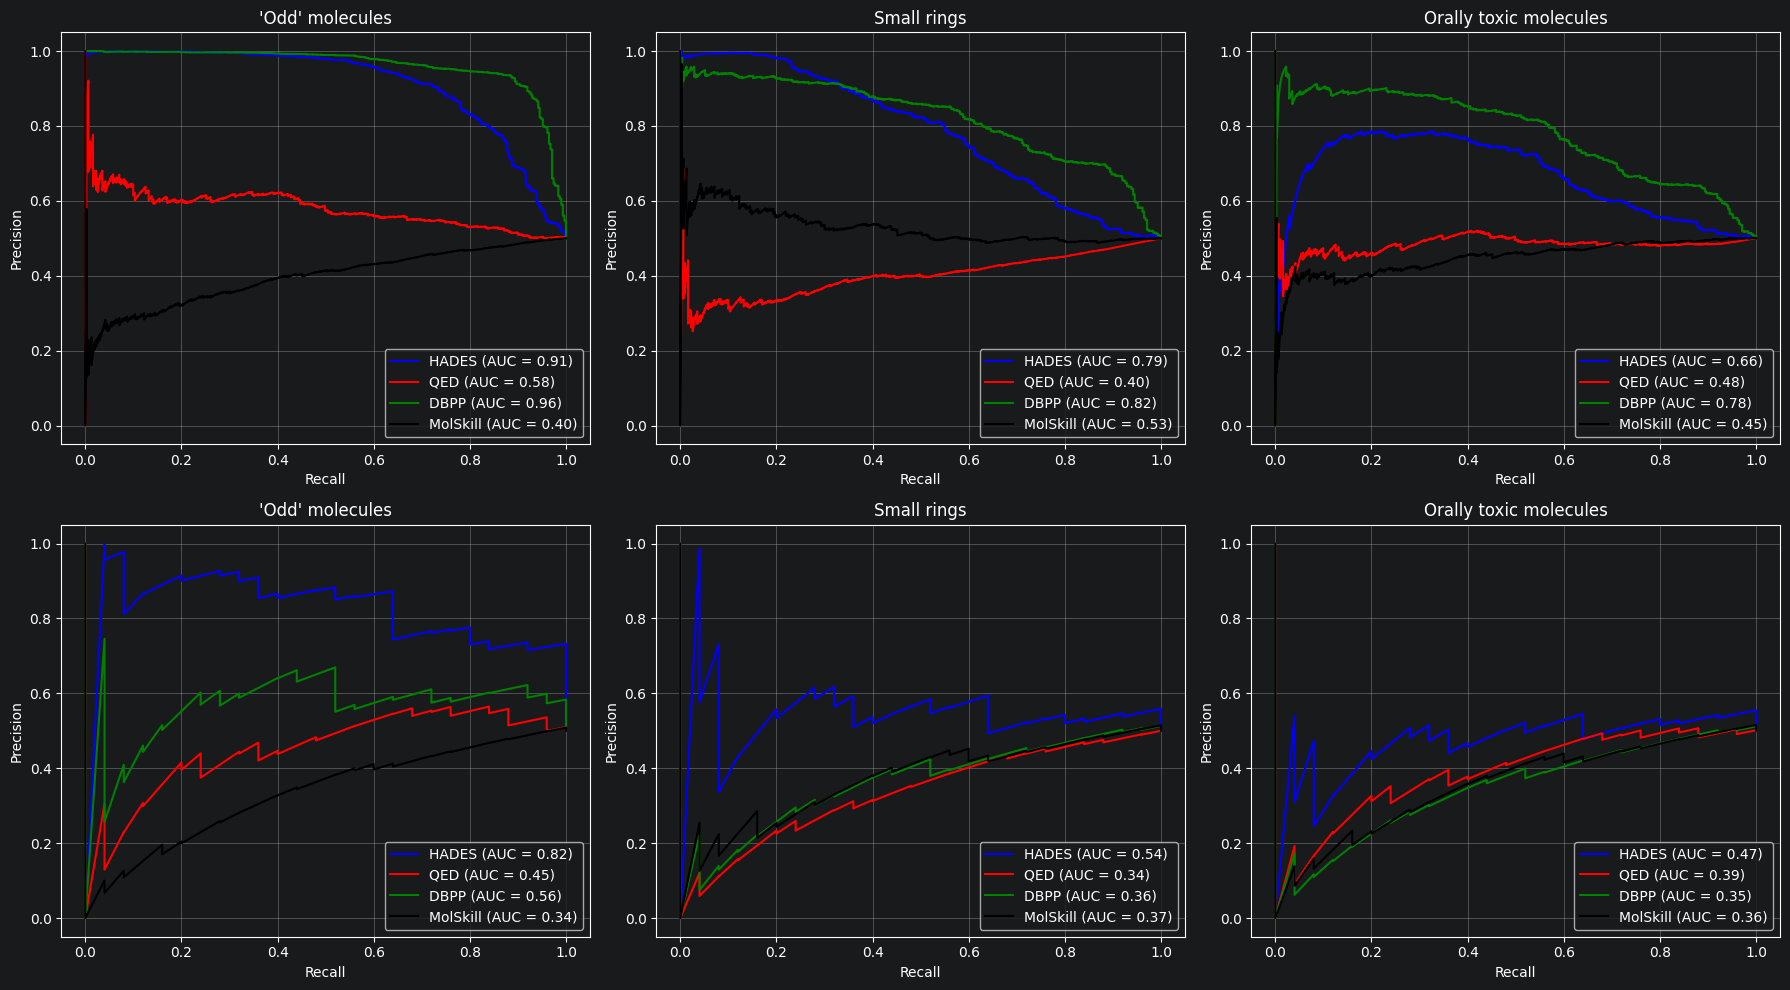

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

models = ['HADES', 'QED', 'DBPP_SCORE', 'MolSkill']
colors = {
    'HADES': 'blue',
    'QED': 'red',
    'DBPP_SCORE': 'green',
    'MolSkill': 'black'
}

d1_list = [odds_final, small_rings, toxicity_panel]
d2_top = final_list_4
d2_bottom = new_2024_after_drugs
titles = ["'Odd' molecules", 'Small rings', 'Orally toxic molecules']


def compute_pr_auc(d1, d2, model):
    # Remove NaNs only for the current model
    d1_clean = d1[d1[model].notna()]
    d2_clean = d2[d2[model].notna()]

    # Safety check (avoid empty inputs)
    if len(d1_clean) == 0 or len(d2_clean) == 0:
        return None, None, None

    y_true = [0] * len(d1_clean) + [1] * len(d2_clean)
    y_scores = d1_clean[model].tolist() + d2_clean[model].tolist()

    weights = (
        [1 / len(d1_clean)] * len(d1_clean) +
        [1 / len(d2_clean)] * len(d2_clean)
    )

    precision, recall, _ = precision_recall_curve(
        y_true, y_scores, sample_weight=weights
    )

    return precision, recall, auc(recall, precision)


fig, axs = plt.subplots(2, 3, figsize=(18, 10))

for col, d1 in enumerate(d1_list):
    for row, d2 in enumerate([d2_top, d2_bottom]):
        ax = axs[row, col]

        for model in models:
            precision, recall, pr_auc = compute_pr_auc(d1, d2, model)

            # Skip models with no valid data
            if precision is None:
                print(f"Skipping {model} due to NaNs")
                continue

            ax.plot(
                recall,
                precision,
                label=f'{model.replace("_SCORE", "")} (AUC = {pr_auc:.2f})',
                color=colors[model]
            )

        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title(titles[col])
        ax.legend(loc='lower right')
        ax.grid(True)

plt.tight_layout()
plt.show()

In [33]:
import os
import pandas as pd

folder_path = './screening libraries all scores'
# Get all CSV file names in the folder
csv_files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

libraries_dict = {}
for i in csv_files:
    name = i.split('.')[0].split('_')[0]
    libraries_dict[name] = pd.read_csv(os.path.join(folder_path, i))

#


In [34]:
def ef(data, score, percent, items='labels'):
    if percent <= 0:
        return 0
    data2 = data.copy()
    ascending = True if score == 'MolSkill' else False
    data2 = data2.sort_values(by=score, ascending=ascending).reset_index(drop=True)
    top_n = int(len(data2) * percent / 100)
    if top_n == 0:
        return 0
    data2_top = data2.iloc[:top_n]
    active_ratio_top = len(data2_top[data2_top[items] == 1]) / len(data2_top)
    active_ratio_all = len(data2[data2[items] == 1]) / len(data2)
    if active_ratio_all == 0:
        return 0
    enrichment_factor = active_ratio_top / active_ratio_all
    return enrichment_factor

In [35]:
import pandas as pd

# Your dictionary of DataFrames (where keys are names and values are the DataFrames)
dfs = libraries_dict

# Percentages and scores to evaluate
percentages = [1, 3, 5, 10]
scores = ['HADES', 'DBPP_SCORE', 'QED', 'MolSkill']

# Storage for results
all_results = []

# Loop through each dataset in the dictionary
for name, df in dfs.items():
    if name == 'SGLT':
        continue
    else:
        ef_results = {}
        for percent in percentages:
            ef_results[percent] = []
            for score in scores:
                ef_val = ef(df, score=score, percent=percent, items='labels')
                ef_results[percent].append(ef_val)

        # Create temporary DataFrame and add a 'Set' column
        ef_df = pd.DataFrame(ef_results, index=scores).T
        ef_df.index.name = 'Percent'
        ef_df.columns.name = 'Score'
        ef_df = ef_df.reset_index()
        ef_df['Set'] = name  # Add the name of the DataFrame as a column

        all_results.append(ef_df)

# Concatenate all results into one DataFrame
final_df = pd.concat(all_results, ignore_index=True)

# Rearrange columns for better readability
final_df = final_df[['Set', 'Percent'] + scores]

# Display the final DataFrame
(final_df)


Score,Set,Percent,HADES,DBPP_SCORE,QED,MolSkill
0,ANDROGENS,1,82.925170,86.530612,0.000000,0.000000
1,ANDROGENS,3,29.808774,29.808774,0.000000,2.384702
2,ANDROGENS,5,17.857143,17.857143,0.000000,1.428571
3,ANDROGENS,10,9.285714,8.928571,0.357143,0.714286
4,pi3k,1,15.414095,0.000000,0.000000,0.000000
5,pi3k,3,7.707047,0.000000,0.000000,0.000000
6,pi3k,5,4.618697,1.539566,0.000000,1.539566
7,pi3k,10,3.077291,4.615936,3.077291,0.769323
8,KRAS,1,20.008750,20.008750,0.000000,0.000000
9,KRAS,3,13.339167,6.669583,0.000000,0.000000


HADES: p-value = 6.44e-05
DBPP_SCORE: p-value = 1.17e-02
QED: p-value = 3.79e-01
MolSkill: p-value = 1.90e-01


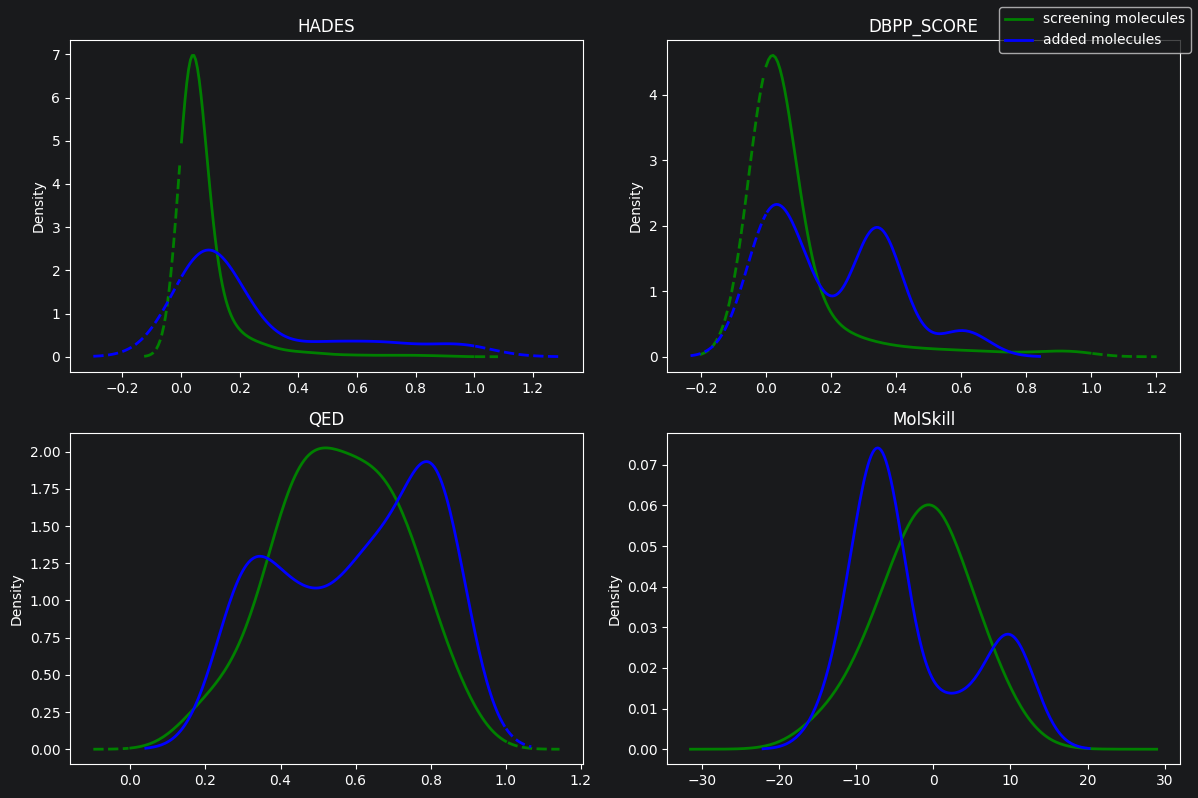

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

def compute_p_value(data, label_name):
    """
    Compute Mann-Whitney U test p-value between label 0 and 1
    """
    group0 = data[data["labels"] == 0][label_name].dropna()
    group1 = data[data["labels"] == 1][label_name].dropna()

    if len(group0) == 0 or len(group1) == 0:
        return None

    stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')
    return p_value


def plot_custom_kde(ax, data, label_name, bw_method=0.4):
    """
    Plot KDE with custom line styles (solid/dotted)
    """
    colors = {0: "green", 1: "blue"}
    labels_dict = {0: "screening molecules", 1: "added molecules"}

    for lbl in [0, 1]:
        subset = data[data["labels"] == lbl][label_name].dropna()

        if len(subset) == 0:
            continue

        kde = sns.kdeplot(subset, ax=ax, lw=2, color=colors[lbl], bw_method=bw_method)
        x, y = kde.get_lines()[-1].get_data()
        kde.get_lines()[-1].remove()

        if label_name.lower() == "molskill":
            ax.plot(x, y, lw=2, color=colors[lbl], label=labels_dict[lbl])
        else:
            mask_inside = (x >= 0) & (x <= 1)
            ax.plot(x[mask_inside], y[mask_inside], lw=2,
                    color=colors[lbl], label=labels_dict[lbl])

            mask_left = x < 0
            mask_right = x > 1
            ax.plot(x[mask_left], y[mask_left], "--", lw=2, color=colors[lbl])
            ax.plot(x[mask_right], y[mask_right], "--", lw=2, color=colors[lbl])

    ax.set_title(label_name)
    ax.set_xlabel("")


def plot_kde_collage(df, score_cols, save_path=None, figsize=(12,8), bw_method=0.4):
    """
    Plot a 2x2 collage of KDE plots and print p-values
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(score_cols):
        p_value = compute_p_value(df, col)
        if p_value is not None:
            print(f"{col}: p-value = {p_value:.2e}")
        else:
            print(f"{col}: p-value = N/A (not enough data)")
        plot_custom_kde(axes[i], df, col, bw_method=bw_method)

    # Add legend once
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='tiff', dpi=300)

    plt.show()


# Example usage
score_cols = ["HADES", "DBPP_SCORE", "QED", "MolSkill"]

plot_kde_collage(libraries_dict['pi3k'], score_cols)

In [37]:
# all scores already calculated
hit_lead_data =pd.read_csv(r'Hit_lead_optimization_data.csv')
df = hit_lead_data.copy()


In [38]:
df['molskill_scaled_initial'] = 1 - (df['initial_MolSkill'] - df['initial_MolSkill'].min()) / (df['initial_MolSkill'].max() - df['initial_MolSkill'].min())
df['molskill_scaled_optimized'] = 1 - (df['optimized_MolSkill'] - df['optimized_MolSkill'].min()) / (df['optimized_MolSkill'].max() - df['optimized_MolSkill'].min())


In [39]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data = {
    "HADES": df["optimied_HADES"] - df["initial_HADES"],
    "DBPP": df["optimized_DBPP"] - df["initial_DBPP"],
    "QED": df["optimized_QED"] - df["initial_QED"],
    "MolSkill": df["molskill_scaled_optimized"] - df["molskill_scaled_initial"]
}



# -------------------------------
# THRESHOLDS
# -------------------------------
positive_thresholds = [0,0.001, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
negative_thresholds = [-0.001, -0.01, -0.02, -0.05, -0.1, -0.2, -0.3, -0.4, -0.5]

# -------------------------------
# CLEAN DATA (convert to pandas Series)
# -------------------------------
data_series = {
    model: pd.Series(pd.to_numeric(values, errors="coerce"))
    for model, values in data.items()
}

# -------------------------------
# RESULT TABLES
# -------------------------------
above_df = pd.DataFrame(index=positive_thresholds, columns=data_series.keys())
below_df = pd.DataFrame(index=negative_thresholds, columns=data_series.keys())

# -------------------------------
# CALCULATIONS
# -------------------------------
for model, values in data_series.items():
    total = values.count()

    above_df[model] = [
        round((values > t).sum() / total * 100, 0) if total > 0 else 0
        for t in positive_thresholds
    ]

    below_df[model] = [
        round((values < t).sum() / total * 100, 0) if total > 0 else 0
        for t in negative_thresholds
    ]

# -------------------------------
# LABELS
# -------------------------------
above_df.index.name = "Improvement > Threshold"
below_df.index.name = "Improvement < Threshold"
above_df.columns.name = below_df.columns.name = "Metric"

# -------------------------------
# OUTPUT
# -------------------------------
print("🔼 Percentage of molecules IMPROVED above thresholds")
print(above_df)

print("\n🔽 Percentage of molecules DEGRADED below thresholds")
print(below_df)

🔼 Percentage of molecules IMPROVED above thresholds
Metric                   HADES  DBPP   QED  MolSkill
Improvement > Threshold                             
0.000                     73.0  62.0  31.0      50.0
0.001                     69.0  60.0  31.0      50.0
0.010                     62.0  55.0  28.0      49.0
0.020                     55.0  49.0  23.0      48.0
0.050                     36.0  39.0  17.0      42.0
0.100                     28.0  32.0  11.0      34.0
0.200                     18.0  24.0   1.0      20.0
0.300                     12.0  22.0   0.0      12.0
0.400                      8.0  16.0   0.0       8.0
0.500                      6.0  14.0   0.0       4.0

🔽 Percentage of molecules DEGRADED below thresholds
Metric                   HADES  DBPP   QED  MolSkill
Improvement < Threshold                             
-0.001                    27.0  35.0  69.0      49.0
-0.010                    21.0  29.0  68.0      44.0
-0.020                    18.0  27.0  64.0     

In [10]:
y_train10 = [int(i/4) for i in y_train['phase']]
y_test10 = [int(i/4) for i in y_test['phase']]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, brier_score_loss, f1_score,
    matthews_corrcoef, average_precision_score, accuracy_score
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample
from sklearn.base import clone
from scipy.spatial.distance import cdist

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def safe_auc(y_true, y_pred):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_pred)

def get_probabilities(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.predict(X, prediction_type='Probability')[:, 1]

def predict_ensemble(models_dict, X):
    probs = [get_probabilities(m, X) for m in models_dict.values()]
    return np.mean(probs, axis=0)

def compute_metrics(y, p):
    if len(y) < 5 or len(np.unique(y)) < 2:
        return {m: np.nan for m in ["N", "AUROC", "AUPRC", "MCC", "F1", "Accuracy", "Brier"]}
    pred = (p >= 0.5).astype(int)
    return {
        "N":        int(len(y)),
        "AUROC":    round(roc_auc_score(y, p), 3),
        "AUPRC":    round(average_precision_score(y, p), 3),
        "MCC":      round(matthews_corrcoef(y, pred), 3),
        "F1":       round(f1_score(y, pred, zero_division=0), 3),
        "Accuracy": round(accuracy_score(y, pred), 3),
        "Brier":    round(brier_score_loss(y, p), 4),
    }

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — CALIBRATION
# Reliability curves with 95 % bootstrap CI + Brier score per model
# ─────────────────────────────────────────────────────────────────────────────

def calibration_analysis(models_dict, X_test, y_test, n_bootstrap=500, n_bins=10):

    X_test = np.array(X_test)
    y_test = np.array(y_test)

    all_models             = dict(models_dict)
    all_models["Ensemble"] = None

    n_models = len(all_models)
    cols     = 3
    rows     = int(np.ceil(n_models / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
    axes = axes.flatten()

    summary_rows = []

    for ax_idx, (name, model) in enumerate(all_models.items()):
        ax = axes[ax_idx]

        prob_full = (predict_ensemble(models_dict, X_test)
                     if name == "Ensemble"
                     else get_probabilities(model, X_test))

        bin_curves, brier_bs = [], []
        grid = np.linspace(0, 1, n_bins)

        for i in range(n_bootstrap):
            idx  = resample(np.arange(len(y_test)), random_state=i)
            y_bs = y_test[idx]
            p_bs = prob_full[idx]
            if len(np.unique(y_bs)) < 2:
                continue
            frac, mean_p = calibration_curve(y_bs, p_bs, n_bins=n_bins,
                                              strategy="uniform")
            brier_bs.append(brier_score_loss(y_bs, p_bs))
            interp = np.interp(grid, mean_p, frac, left=np.nan, right=np.nan)
            bin_curves.append(interp)

        bin_mat = np.array(bin_curves)
        lo = np.nanpercentile(bin_mat, 2.5,  axis=0)
        hi = np.nanpercentile(bin_mat, 97.5, axis=0)

        frac_obs, mean_pred = calibration_curve(y_test, prob_full, n_bins=n_bins,
                                                 strategy="uniform")

        ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
        ax.fill_between(grid, lo, hi, alpha=0.20, color="#3A6EA5",
                        label="95 % bootstrap CI")
        ax.plot(mean_pred, frac_obs, "o-", color="#3A6EA5", lw=2,
                label="Observed (full test)")

        bs_mean = np.mean(brier_bs)
        bs_std  = np.std(brier_bs)
        ax.set_title(f"{name}\nBrier = {bs_mean:.4f} ± {bs_std:.4f}", fontsize=10)
        ax.set_xlabel("Mean predicted probability")
        ax.set_ylabel("Fraction of positives")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)

        summary_rows.append({
            "Model":             name,
            "Brier Mean":        round(bs_mean, 4),
            "Brier Std":         round(bs_std,  4),
            "Brier 95% CI Low":  round(np.percentile(brier_bs, 2.5),  4),
            "Brier 95% CI High": round(np.percentile(brier_bs, 97.5), 4),
        })

    for j in range(ax_idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Reliability Diagrams with Bootstrap 95 % Confidence Intervals",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("calibration_ci.png", dpi=150, bbox_inches="tight")
    plt.close()

    cal_df = pd.DataFrame(summary_rows)
    print("\n── Calibration Summary ──")
    print(cal_df.to_string(index=False))
    return cal_df


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — APPLICABILITY DOMAIN
# Mahalanobis distance; threshold defined on training-set LOO distances only
# ─────────────────────────────────────────────────────────────────────────────

def applicability_domain_analysis(models_dict, X_train, y_train, X_test, y_test, z=1.5):

    X_train = np.array(X_train)
    X_test  = np.array(X_test)
    y_train = np.array(y_train)
    y_test  = np.array(y_test)

    scaler      = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_train)
    X_te_scaled = scaler.transform(X_test)

    cov     = np.cov(X_tr_scaled, rowvar=False)
    cov_inv = np.linalg.pinv(cov)

    # Threshold from training-set LOO nearest-neighbour distances
    d_train = cdist(X_tr_scaled, X_tr_scaled, metric='mahalanobis', VI=cov_inv)
    np.fill_diagonal(d_train, np.inf)
    d_train_nn = d_train.min(axis=1)
    threshold  = d_train_nn.mean() + z * d_train_nn.std()

    # Test-set distances to nearest training point
    d_test    = cdist(X_te_scaled, X_tr_scaled, metric='mahalanobis', VI=cov_inv)
    d_test_nn = d_test.min(axis=1)
    in_ad     = d_test_nn <= threshold

    print(f"\n── Applicability Domain (Mahalanobis, z={z}) ──")
    print(f"  Threshold (training LOO): {threshold:.4f}")
    print(f"  In-domain    : {in_ad.sum():>5d} / {len(in_ad)}  ({100*in_ad.mean():.1f} %)")
    print(f"  Out-of-domain: {(~in_ad).sum():>5d} / {len(in_ad)}  ({100*(~in_ad).mean():.1f} %)")

    # Performance stratified by AD membership
    all_models             = dict(models_dict)
    all_models["Ensemble"] = None

    rows = []
    for name, model in all_models.items():
        prob = (predict_ensemble(models_dict, X_test)
                if name == "Ensemble"
                else get_probabilities(model, X_test))
        for subset, mask in [("In-AD",  in_ad),
                              ("Out-AD", ~in_ad),
                              ("Full",   np.ones(len(y_test), dtype=bool))]:
            m = compute_metrics(y_test[mask], prob[mask])
            m.update({"Model": name, "Subset": subset})
            rows.append(m)

    df_ad = pd.DataFrame(rows)[["Model", "Subset", "N", "AUROC", "AUPRC",
                                  "MCC", "F1", "Accuracy", "Brier"]]
    print("\n── AD-Stratified Performance ──")
    print(df_ad.to_string(index=False))

    # Bar chart — ensemble only
    ens     = df_ad[df_ad["Model"] == "Ensemble"].set_index("Subset")
    metrics = ["AUROC", "AUPRC", "MCC", "F1", "Accuracy", "Brier"]
    x       = np.arange(len(metrics))
    width   = 0.25
    colors  = {"In-AD": "#3A6EA5", "Out-AD": "#E07B39", "Full": "#5BAD6F"}

    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (subset, color) in enumerate(colors.items()):
        vals = [ens.loc[subset, m] if not np.isnan(ens.loc[subset, m]) else 0
                for m in metrics]
        ax.bar(x + i * width, vals, width, label=subset, color=color, alpha=0.85)

    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics, fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_ylim(0, 1.08)
    ax.set_title("Ensemble Performance Stratified by Applicability Domain", fontsize=13)
    ax.legend(fontsize=10)
    ax.axhline(0.5, color="grey", lw=0.8, ls="--")
    plt.tight_layout()
    plt.savefig("ad_performance.png", dpi=150, bbox_inches="tight")
    plt.close()

    # Distance scatter — in-AD vs out-of-AD (jitter for visibility)
    np.random.seed(RANDOM_STATE)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(d_test_nn[in_ad],
               np.random.uniform(0, 1, in_ad.sum()),
               color="#3A6EA5", alpha=0.4, s=12, label="In-AD")
    ax.scatter(d_test_nn[~in_ad],
               np.random.uniform(0, 1, (~in_ad).sum()),
               color="#E07B39", alpha=0.4, s=12, label="Out-of-AD")
    ax.axvline(threshold, color="black", ls="--", lw=1.5,
               label=f"Threshold = {threshold:.3f}")
    ax.set_xlabel("Mahalanobis distance to nearest training point", fontsize=12)
    ax.set_ylabel("Jitter (display only)", fontsize=11)
    ax.set_title("Test-Set Applicability Domain Coverage", fontsize=13)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("ad_coverage.png", dpi=150, bbox_inches="tight")
    plt.close()

    return df_ad, in_ad, threshold


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — ROBUSTNESS
# 3a. Metric variance across 10-fold stratified CV (evidenced stability)
# 3b. Large-error analysis (fraction of compounds with |y − ŷ| > threshold)
# ─────────────────────────────────────────────────────────────────────────────

def robustness_analysis(models_dict, X_train, y_train, X_test, y_test, n_splits=10):

    X_train = np.array(X_train)
    X_test  = np.array(X_test)
    y_train = np.array(y_train)
    y_test  = np.array(y_test)

    X_all = np.vstack([X_train, X_test])
    y_all = np.concatenate([y_train, y_test])

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    fold_records = {name: {"AUROC": [], "Brier": []}
                    for name in list(models_dict.keys()) + ["Ensemble"]}

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_all, y_all), 1):
        X_tr, X_va = X_all[tr_idx], X_all[va_idx]
        y_tr, y_va = y_all[tr_idx], y_all[va_idx]

        fold_models = {}
        for name, model in models_dict.items():
            m = clone(model)
            m.fit(X_tr, y_tr)
            fold_models[name] = m
            prob = get_probabilities(m, X_va)
            fold_records[name]["AUROC"].append(safe_auc(y_va, prob))
            fold_records[name]["Brier"].append(brier_score_loss(y_va, prob))

        prob_ens = predict_ensemble(fold_models, X_va)
        fold_records["Ensemble"]["AUROC"].append(safe_auc(y_va, prob_ens))
        fold_records["Ensemble"]["Brier"].append(brier_score_loss(y_va, prob_ens))

    # Summary table
    cv_rows = []
    for name, vals in fold_records.items():
        aucs   = np.array(vals["AUROC"])
        briers = np.array(vals["Brier"])
        cv_rows.append({
            "Model":      name,
            "AUROC Mean": round(np.nanmean(aucs),   4),
            "AUROC Std":  round(np.nanstd(aucs),    4),
            "AUROC CV%":  round(np.nanstd(aucs) / np.nanmean(aucs) * 100, 2),
            "Brier Mean": round(np.nanmean(briers), 4),
            "Brier Std":  round(np.nanstd(briers),  4),
        })

    cv_df = pd.DataFrame(cv_rows)
    print("\n── CV Variance (robustness) ──")
    print(cv_df.to_string(index=False))

    # Box plots
    model_names = list(fold_records.keys())
    box_colors  = ["#3A6EA5", "#5BAD6F", "#E07B39", "#8E6DBE", "#D4596A", "#6AB0C8"]
    fig, axes   = plt.subplots(1, 2, figsize=(13, 5))

    for ax, metric, ylabel in zip(axes,
                                   ["AUROC", "Brier"],
                                   ["AUROC", "Brier Score"]):
        data = [fold_records[n][metric] for n in model_names]
        bp   = ax.boxplot(data, patch_artist=True,
                          medianprops=dict(color="black", lw=2))
        for patch, color in zip(bp["boxes"], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.75)
        ax.set_xticklabels(model_names, rotation=25, ha="right", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f"{ylabel} across {n_splits}-fold CV", fontsize=12)

    plt.suptitle("Metric Variance across Stratified CV Splits", fontsize=13)
    plt.tight_layout()
    plt.savefig("robustness_cv.png", dpi=150, bbox_inches="tight")
    plt.close()

    # Large-error analysis
    all_probs = {name: get_probabilities(m, X_test)
                 for name, m in models_dict.items()}
    all_probs["Ensemble"] = predict_ensemble(models_dict, X_test)

    thresholds = [0.3, 0.5, 0.7]
    err_rows   = []
    for name, prob in all_probs.items():
        error = np.abs(y_test.astype(float) - prob)
        row   = {"Model": name}
        for thr in thresholds:
            row[f"|err|>{thr} (%)"] = round(100 * (error > thr).mean(), 2)
        err_rows.append(row)

    err_df = pd.DataFrame(err_rows)
    print("\n── Large-Error Analysis ──")
    print(err_df.to_string(index=False))

    # Cumulative error-rate curves
    xs          = np.linspace(0, 1, 100)
    line_colors = ["#3A6EA5", "#5BAD6F", "#E07B39", "#8E6DBE", "#D4596A", "black"]
    fig, ax     = plt.subplots(figsize=(8, 5))

    for (name, prob), color in zip(all_probs.items(), line_colors):
        error = np.abs(y_test.astype(float) - prob)
        frac  = [(error > t).mean() for t in xs]
        lw    = 2.5 if name == "Ensemble" else 1.2
        ls    = "-"  if name == "Ensemble" else "--"
        ax.plot(xs, frac, lw=lw, ls=ls, color=color, label=name)

    for thr in thresholds:
        ax.axvline(thr, color="grey", lw=0.8, ls=":")
        ax.text(thr + 0.01, 0.92, str(thr), fontsize=9, color="grey")

    ax.set_xlabel("Error threshold  |y − ŷ|", fontsize=12)
    ax.set_ylabel("Fraction of compounds with error > threshold", fontsize=12)
    ax.set_title("Cumulative Large-Error Rate", fontsize=13)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("large_errors.png", dpi=150, bbox_inches="tight")
    plt.close()

    return cv_df, err_df


# ─────────────────────────────────────────────────────────────────────────────
# MAIN ENTRY POINT
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_model_validity(models_dict, X_train, y_train, X_test, y_test,
                             n_bootstrap=500, n_cv_splits=10, ad_z=1.5):
    """
    Runs all three OECD-aligned validation analyses:
      1. calibration_analysis     — reliability curves + Brier score with bootstrap CI
      2. applicability_domain_analysis — Mahalanobis AD (training-LOO threshold),
                                         performance stratified by in/out-of-domain
      3. robustness_analysis      — CV metric variance + large-error analysis

    Saves five figures:
      calibration_ci.png | ad_performance.png | ad_coverage.png
      robustness_cv.png  | large_errors.png

    Returns a dict of four summary DataFrames.
    """
    print("\n" + "=" * 60)
    print("SECTION 1 — CALIBRATION")
    print("=" * 60)
    cal_df = calibration_analysis(
        models_dict, X_test, y_test,
        n_bootstrap=n_bootstrap
    )

    print("\n" + "=" * 60)
    print("SECTION 2 — APPLICABILITY DOMAIN")
    print("=" * 60)
    ad_df, in_ad, threshold = applicability_domain_analysis(
        models_dict, X_train, y_train, X_test, y_test,
        z=ad_z
    )

    print("\n" + "=" * 60)
    print("SECTION 3 — ROBUSTNESS")
    print("=" * 60)
    cv_df, err_df = robustness_analysis(
        models_dict, X_train, y_train, X_test, y_test,
        n_splits=n_cv_splits
    )

    print("\n[Done] Figures saved:")
    print("  calibration_ci.png | ad_performance.png | ad_coverage.png"
          " | robustness_cv.png | large_errors.png")

    return {
        "calibration":    cal_df,
        "ad_performance": ad_df,
        "cv_variance":    cv_df,
        "large_errors":   err_df,
    }


# ─────────────────────────────────────────────────────────────────────────────
# RUN
# ─────────────────────────────────────────────────────────────────────────────

results = evaluate_model_validity(
    models_dict = models_balanced,
    X_train     = X_train_final[descriptors],
    y_train     = y_train10,
    X_test      = X_test_final[descriptors],
    y_test      = y_test10,
    n_bootstrap = 500,
    n_cv_splits = 10,
    ad_z        = 1.5,
)


